In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../data/train.csv')

In [7]:
# Drop CustomerID - it is just an identifier
df = df.drop('CustomerID', axis=1)

# Encode categorical columns
cat_cols = ['SubscriptionType', 'PaymentMethod', 'ContentType', 'GenrePreference', 'DeviceRegistered', 'Gender', 'PaperlessBilling', 'MultiDeviceAccess', 'ParentalControl', "SubtitlesEnabled"]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# check if the there are any missing values
if df.isnull().sum().sum() > 0:
    df.dropna()

print(df.shape)

(243787, 20)


In [8]:
#Building the Model

X = df.drop(['Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, list(model.classes_).index(1)] # churn probability per customer

              precision    recall  f1-score   support

      Stayed       0.86      0.92      0.89     39921
     Churned       0.45      0.30      0.36      8837

    accuracy                           0.81     48758
   macro avg       0.65      0.61      0.62     48758
weighted avg       0.78      0.81      0.79     48758



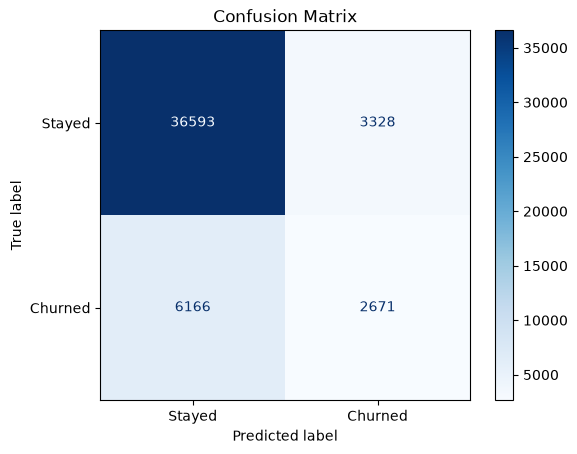

In [9]:
# Evaluation

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [14]:
thresholds = [0.20, 0.25, 0.30, 0.37, 0.40, 0.45, 0.50]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.244 | Recall: 0.888 | F1: 0.382
Threshold: 0.25 | Precision: 0.270 | Recall: 0.815 | F1: 0.405
Threshold: 0.30 | Precision: 0.300 | Recall: 0.727 | F1: 0.425
Threshold: 0.37 | Precision: 0.342 | Recall: 0.586 | F1: 0.432
Threshold: 0.40 | Precision: 0.363 | Recall: 0.522 | F1: 0.428
Threshold: 0.45 | Precision: 0.396 | Recall: 0.421 | F1: 0.408
Threshold: 0.50 | Precision: 0.436 | Recall: 0.321 | F1: 0.370


In [15]:
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# Show thresholds that achieve at least 60% recall
results_df[results_df['recall'] >= 0.60].sort_values(
    'precision',
    ascending=False
).head(10)

c:\Users\kumar\Desktop\Gautam\Customer-Churn-Rate\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kumar\Desktop\Gautam\Customer-Churn-Rate\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,threshold,precision,recall,f1
26,0.36,0.334919,0.605409,0.431260
25,0.35,0.328713,0.625325,0.430911
24,0.34,0.322926,0.644902,0.430357
23,0.33,0.317216,0.665950,0.429735
22,0.32,0.310780,0.685074,0.427588
21,0.31,0.305662,0.706235,0.426662
20,0.30,0.299739,0.727283,0.424519
19,0.29,0.294267,0.748105,0.422388
18,0.28,0.287810,0.763834,0.418086
17,0.27,0.282016,0.782732,0.414639
